In [1]:
#TO DO funzioni che si ripetono 
#from utils import pairs_generations

import torch
import numpy as np
import random
import os
import tarfile
from nats_bench import create
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader, random_split
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from dataset_loader import NASDatasetFactory,load_nas201_api,arch_to_tensor
from model import VAE_dist,vae_accuracy_loss,FlowNet,flow_loss
from torch.utils.data import Subset, DataLoader
import torch
from train_flownas import train_one_epoch, pretrain_and_freeze_vae
from utils import build_accuracy_pairs, generate_archs,decoded_x_to_nas201_arch, query_nas201_accuracy,set_seed

KeyboardInterrupt: 

In [ ]:
set_seed()

In [ ]:
DATASET_NAME = "NAS201"


In [ ]:
api = load_nas201_api()


Dataset NAS201 già estratto.
Architetture NAS201 totali: 15625


## Data loading 

In [ ]:

# 2. Crea dataset Torch da NAS201
dataset = NASDatasetFactory.create(
    benchmark_name="NAS201",
    api=api,
    dataset_name="cifar10",      # puoi mettere anche "cifar100" o "imagenet16-120"
    metric="test-accuracy",
    flatten=True,
    normalize_y=True,
)

# 3. Test base
print("Numero architetture:", len(dataset))

x0, y0 = dataset[0]
print("x0 shape:", x0.shape)
print("y0:", y0)
print("y0 shape:", y0.shape)

# 4. Split train/test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Numero architetture: 4


ValueError: too many values to unpack (expected 2)

## Analyzing 1 epoch of Training:

1. VAE TRAINING ON FIRST RANDOMLY GENERATED SET OF ARCHITECTURES

In [ ]:
import pandas as pd
def save_generated_archs_to_csv(loader, csv_path="generated_architectures.csv"):
    rows = []
    global_idx = 0

    for batch in loader:

        # Caso standard: batch = (x, y)
        if isinstance(batch, (list, tuple)):
            x_batch, y_batch = batch
        else:
            x_batch = batch
            y_batch = None

        # Porto tutto su CPU
        if isinstance(x_batch, torch.Tensor):
            x_batch = x_batch.detach().cpu()
        else:
            x_batch = torch.tensor(x_batch)

        if y_batch is not None:
            if isinstance(y_batch, torch.Tensor):
                y_batch = y_batch.detach().cpu()
            else:
                y_batch = torch.tensor(y_batch)

        # Se x_batch è un singolo esempio, aggiungo batch dimension
        if x_batch.dim() == 1:
            x_batch = x_batch.unsqueeze(0)

        batch_size = x_batch.size(0)

        for i in range(batch_size):

            x = x_batch[i].reshape(-1).numpy()

            row = {
                "index": global_idx
            }

            # Salvo accuracy/label se presente
            if y_batch is not None:
                y_val = y_batch[i]

                if isinstance(y_val, torch.Tensor):
                    y_val = float(y_val.reshape(-1)[0].item())
                else:
                    y_val = float(y_val)

                row["accuracy"] = y_val

            # Salvo feature x_0, x_1, ..., x_503
            for j, value in enumerate(x):
                row[f"x_{j}"] = float(value)

            rows.append(row)
            global_idx += 1

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)

    print(f"File salvato in: {csv_path}")
    print("Numero architetture salvate:", len(df))
    print("Numero colonne:", len(df.columns))

    return df

In [ ]:
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

N = 256
vae_epochs = 300
beta = 0.0
lambda_acc = 5

# 1. Genera 256 architetture random da NAS201 train
train_loader = generate_archs(
    dataset=train_dataset,
    N=N
)

df_generated = save_generated_archs_to_csv(
    train_loader,
    csv_path="nas201_initial_population.csv"
)

# 2. Crea VAE_dist
model = VAE_dist(
    LATENT_DIM=16
).to(DEVICE)

vae_optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# 3. Training VAE sui 256 esempi
model.train()

for epoch in range(vae_epochs):

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    total_acc = 0.0

    for x, y in train_loader:

        x = x.to(DEVICE).float()
        y = y.to(DEVICE).float()

        # --------------------------------------------------
        # Forward VAE_dist
        # --------------------------------------------------
        recon_logits, recon_probs, mu, logvar, pred_acc = model(x)

        # --------------------------------------------------
        # Loss VAE_dist + accuracy prediction
        # --------------------------------------------------
        loss, recon_loss, kl_loss, acc_loss = vae_accuracy_loss(
            recon_logits=recon_logits,
            x=x,
            mu=mu,
            logvar=logvar,
            acc_pred=pred_acc,
            true_acc=y,
            beta=beta,
            lambda_acc=lambda_acc
        )

        # --------------------------------------------------
        # Backward
        # --------------------------------------------------
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
        total_acc += acc_loss.item()

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"loss={total_loss:.4f} | "
            f"recon={total_recon:.4f} | "
            f"kl={total_kl:.4f} | "
            f"acc_loss={total_acc:.4f}"
        )

Using device: cuda


File salvato in: nas201_initial_population.csv
Numero architetture salvate: 256
Numero colonne: 98
Epoch 000 | loss=16.3200 | recon=6.9242 | kl=0.0158 | acc_loss=1.8792
Epoch 050 | loss=2.5985 | recon=2.3269 | kl=4.8810 | acc_loss=0.0543
Epoch 100 | loss=2.1988 | recon=2.0800 | kl=17.3805 | acc_loss=0.0238
Epoch 150 | loss=1.0120 | recon=0.9753 | kl=55.5327 | acc_loss=0.0073
Epoch 200 | loss=0.3508 | recon=0.3339 | kl=87.0327 | acc_loss=0.0034
Epoch 250 | loss=0.0786 | recon=0.0702 | kl=126.2990 | acc_loss=0.0017


In [ ]:
# ============================================================
# CHECK RICOSTRUZIONE DOPO TRAINING
# ============================================================
NUM_NODES = 4
NUM_OPS = 6
NUM_EDGES = NUM_NODES * NUM_NODES

model.eval()

all_cell_acc = []
perfect_reconstructions = 0
total_archs = 0

original_archs = []
reconstructed_archs = []
true_accs = []
pred_accs = []

with torch.no_grad():

    for x, y in train_loader:

        x = x.to(DEVICE).float()
        y = y.to(DEVICE).float()

        # Forward sul VAE già addestrato
        recon_logits, recon_probs, mu, logvar, pred_acc = model(x)

        # ----------------------------------------------------
        # Ricavo la matrice discreta originale
        # x: [batch, 96]
        # -> [batch, NUM_OPS, NUM_NODES, NUM_NODES]
        # -> [batch, NUM_NODES, NUM_NODES, NUM_OPS]
        # -> [batch, NUM_NODES, NUM_NODES]
        # ----------------------------------------------------
        x_reshaped = x.reshape(
            x.size(0),
            NUM_OPS,
            NUM_NODES,
            NUM_NODES
        )

        target_onehot = x_reshaped.permute(0, 2, 3, 1)

        target_ops = target_onehot.argmax(dim=-1)

        # ----------------------------------------------------
        # Ricostruzione discreta del modello
        # recon_logits: [batch, NUM_NODES, NUM_NODES, NUM_OPS]
        # ----------------------------------------------------
        recon_ops = recon_logits.argmax(dim=-1)

        # ----------------------------------------------------
        # Accuracy cella per cella
        # ----------------------------------------------------
        batch_cell_acc = (recon_ops == target_ops).float().mean(dim=(1, 2))

        all_cell_acc.extend(batch_cell_acc.cpu().tolist())

        # ----------------------------------------------------
        # Architetture perfettamente ricostruite
        # ----------------------------------------------------
        batch_perfect = (recon_ops == target_ops).all(dim=(1, 2))

        perfect_reconstructions += batch_perfect.sum().item()
        total_archs += x.size(0)

        # Salvo per visualizzare dopo
        original_archs.append(target_ops.cpu())
        reconstructed_archs.append(recon_ops.cpu())
        true_accs.append(y.cpu())
        pred_accs.append(pred_acc.squeeze(-1).cpu())


# ============================================================
# STATISTICHE GLOBALI
# ============================================================

original_archs = torch.cat(original_archs, dim=0)
reconstructed_archs = torch.cat(reconstructed_archs, dim=0)
true_accs = torch.cat(true_accs, dim=0)
pred_accs = torch.cat(pred_accs, dim=0)

mean_cell_acc = sum(all_cell_acc) / len(all_cell_acc)
perfect_rate = perfect_reconstructions / total_archs

print("\n========== RISULTATI RICOSTRUZIONE ==========")
print(f"Architetture controllate: {total_archs}")
print(f"Accuracy media cella per cella: {mean_cell_acc:.4f}")
print(f"Ricostruzioni perfette: {perfect_reconstructions}/{total_archs}")
print(f"Percentuale ricostruzioni perfette: {perfect_rate:.4f}")


========== RISULTATI RICOSTRUZIONE ==========
Architetture controllate: 256
Accuracy media cella per cella: 1.0000
Ricostruzioni perfette: 256/256
Percentuale ricostruzioni perfette: 1.0000


2. LATENT SPACE EMBEDDING EXTRACTION

In [ ]:
model.eval()

z_all = []
y_all = []

with torch.no_grad():
    for x, y in train_loader:

        x = x.to(DEVICE).float()
        y = y.float().view(-1)

        mu, logvar = model.encode(x)

        z_all.append(mu.cpu())
        y_all.append(y.cpu())

z_all = torch.cat(z_all, dim=0)
y_all = torch.cat(y_all, dim=0)

print("z_all shape:", z_all.shape)
print("y_all shape:", y_all.shape)

print("y min:", y_all.min().item())
print("y max:", y_all.max().item())
print("y mean:", y_all.mean().item())

z_all shape: torch.Size([256, 16])
y_all shape: torch.Size([256])
y min: 0.10000000149011612
y max: 0.9406332969665527
y mean: 0.8689886927604675


3. PAIRS GENERATION FOR FLOW MATCHING 

In [ ]:
pairs_x, pairs_target= build_accuracy_pairs(
    X=z_all,
    y=y_all,
    K=50,
    min_delta_acc=0.0,
    seed=42
)

print("pairs_x shape:", pairs_x.shape)
print("pairs_target shape:", pairs_target.shape)
print("numero coppie:", len(pairs_x))

pairs_x shape: torch.Size([254, 16])
pairs_target shape: torch.Size([254, 16])
numero coppie: 254


In [ ]:
target_mean = pairs_target.mean(dim=0, keepdim=True)
target_std = pairs_target.std(dim=0, keepdim=True) + 1e-8


4. FLOW TRAINING 

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

if len(pairs_x) == 0:
    print("Nessuna coppia trovata: prova ad aumentare K o abbassare min_delta_acc.")
else:
    pairs_dataset = TensorDataset(pairs_x, pairs_target)

    pairs_loader = DataLoader(
        pairs_dataset,
        batch_size=64,
        shuffle=True
    )

    flow = FlowNet(dim=16).to(DEVICE)

    flow_optimizer = torch.optim.Adam(
        flow.parameters(),
        lr=1e-3
    )

    flow_epochs = 100

    flow.train()

    for epoch in range(flow_epochs):

        total_flow_loss = 0.0

        for z_start, direction_target in pairs_loader:

            z_start = z_start.to(DEVICE).float()
            direction_target = direction_target.to(DEVICE).float()

            pred_direction = flow(z_start)

            loss = F.mse_loss(pred_direction, direction_target)

            flow_optimizer.zero_grad()
            loss.backward()
            flow_optimizer.step()

            total_flow_loss += loss.item()

        if epoch % 20 == 0:
            print(
                f"Flow epoch {epoch:03d} | "
                f"loss={total_flow_loss:.6f}"
            )

Flow epoch 000 | loss=45.335337
Flow epoch 020 | loss=27.851743
Flow epoch 040 | loss=24.746214
Flow epoch 060 | loss=22.740599
Flow epoch 080 | loss=20.971257


In [ ]:
print("pairs_x shape:", pairs_x.shape)
print("pairs_target shape:", pairs_target.shape)

print("target min:", pairs_target.min().item())
print("target max:", pairs_target.max().item())
print("target mean:", pairs_target.mean().item())
print("target std:", pairs_target.std().item())

target_norm = torch.norm(pairs_target, dim=1)
print("target norm mean:", target_norm.mean().item())
print("target norm std:", target_norm.std().item())
print("target norm min:", target_norm.min().item())
print("target norm max:", target_norm.max().item())

pairs_x shape: torch.Size([254, 16])
pairs_target shape: torch.Size([254, 16])
target min: -10.319485664367676
target max: 13.350923538208008
target mean: 0.20317819714546204
target std: 3.393059015274048
target norm mean: 13.454901695251465
target norm std: 1.9496972560882568
target norm min: 6.496988296508789
target norm max: 18.783519744873047


5. GENERATING NEW ARCHITECTURES FROM FLOW DIRECTION 

In [ ]:
flow.eval()

alpha = 0.5

with torch.no_grad():

    z_start = z_all.to(DEVICE).float()

    direction = flow(z_start)

    z_new = z_start + alpha * direction

print("z_new shape:", z_new.shape)

z_new shape: torch.Size([256, 16])


6. DECODING ARCHITECTURES 

In [ ]:
model.eval()

with torch.no_grad():

    recon_logits_new, recon_probs_new = model.decode(
        z_new.to(DEVICE).float()
    )

    recon_probs_new = recon_probs_new.detach().cpu()

    new_archs = []
    new_accs = []
    new_infos = []

    for i in range(recon_probs_new.shape[0]):

        # recon_probs_new[i]: [4, 4, 6]
        x_decoded = recon_probs_new[i]
        x_decoded = x_decoded.permute(2, 0, 1)  # [6, 4, 4]
        x_decoded = x_decoded.reshape(-1)       # [96]

        arch_str = decoded_x_to_nas201_arch(
            x_decoded
        )

        acc, info = query_nas201_accuracy(
            api=api,
            arch_str=arch_str,
            dataset_name="cifar10",
            hp="200",
            metric="test-accuracy"
        )

        if acc is None:
            continue

        acc = float(acc) / 100.0

        new_archs.append(arch_str)
        new_accs.append(acc)
        new_infos.append(info)

    print("Prime architetture generate:")

    for i in range(min(5, len(new_archs))):
        print(i)
        print("arch:", new_archs[i])
        print("acc:", new_accs[i])
        print()

print("recon_logits_new shape:", recon_logits_new.shape)
print("recon_probs_new shape:", recon_probs_new.shape)
print("recon_probs_new min:", recon_probs_new.min().item())
print("recon_probs_new max:", recon_probs_new.max().item())

Prime architetture generate:
0
arch: |nor_conv_3x3~0|+|none~0|nor_conv_3x3~1|+|nor_conv_3x3~0|skip_connect~1|nor_conv_1x1~2|
acc: 0.9293

1
arch: |avg_pool_3x3~0|+|skip_connect~0|nor_conv_3x3~1|+|none~0|avg_pool_3x3~1|nor_conv_1x1~2|
acc: 0.8985

2
arch: |nor_conv_3x3~0|+|skip_connect~0|none~1|+|skip_connect~0|skip_connect~1|nor_conv_1x1~2|
acc: 0.9241499999999999

3
arch: |none~0|+|none~0|nor_conv_3x3~1|+|nor_conv_3x3~0|avg_pool_3x3~1|nor_conv_1x1~2|
acc: 0.921

4
arch: |nor_conv_3x3~0|+|avg_pool_3x3~0|none~1|+|avg_pool_3x3~0|nor_conv_3x3~1|nor_conv_3x3~2|
acc: 0.92405

recon_logits_new shape: torch.Size([256, 4, 4, 6])
recon_probs_new shape: torch.Size([256, 4, 4, 6])
recon_probs_new min: 0.0
recon_probs_new max: 1.0


In [ ]:
import pandas as pd
import torch
import numpy as np


def save_generated_nas201_like_dataset_csv(
    model,
    z_new,
    api,
    DEVICE="cuda",
    dataset_name="cifar10",
    hp="200",
    metric="test-accuracy",
    csv_path="generated_nas201.csv"
):
    """
    Decodifica z_new, converte ogni architettura NAS201,
    calcola l'accuracy e salva un CSV nel formato:

    index, accuracy, x_0, x_1, ..., x_95

    I valori x_0...x_95 vengono salvati come one-hot 0/1.
    """

    model.eval()
    rows = []

    with torch.no_grad():

        recon_logits_new, recon_probs_new = model.decode(
            z_new.to(DEVICE).float()
        )

        recon_probs_new = recon_probs_new.detach().cpu()

        for i in range(recon_probs_new.shape[0]):

            # --------------------------------------------------
            # recon_probs_new[i] shape attesa: [4, 4, 6]
            # --------------------------------------------------
            x_probs = recon_probs_new[i]

            # --------------------------------------------------
            # Discretizzazione one-hot sulla dimensione operazioni
            # Se shape è [4, 4, 6], la dimensione operazioni è l'ultima.
            # --------------------------------------------------
            op_idx = torch.argmax(x_probs, dim=-1)  # [4, 4]

            x_onehot = torch.zeros_like(x_probs)    # [4, 4, 6]
            x_onehot.scatter_(
                dim=-1,
                index=op_idx.unsqueeze(-1),
                value=1.0
            )

            # --------------------------------------------------
            # Per decoded_x_to_nas201_arch usi il formato [6, 4, 4] flatten
            # --------------------------------------------------
            x_decoded = x_onehot.permute(2, 0, 1)   # [6, 4, 4]
            x_decoded = x_decoded.reshape(-1)       # [96]

            arch_str = decoded_x_to_nas201_arch(
                x_decoded
            )

            acc, info = query_nas201_accuracy(
                api=api,
                arch_str=arch_str,
                dataset_name=dataset_name,
                hp=hp,
                metric=metric
            )

            if acc is None:
                continue

            acc = float(acc) / 100.0

            row = {
                "index": len(rows),
                "accuracy": acc
            }

            x_np = x_decoded.detach().cpu().numpy().reshape(-1)

            for j, value in enumerate(x_np):
                row[f"x_{j}"] = float(value)

            rows.append(row)

    columns = ["index", "accuracy"] + [f"x_{j}" for j in range(96)]

    df = pd.DataFrame(rows, columns=columns)
    df.to_csv(csv_path, index=False)

    print(f"File salvato in: {csv_path}")
    print("Numero architetture salvate:", len(df))
    print("Shape dataframe:", df.shape)

    return df

In [ ]:
df_generated = save_generated_nas201_like_dataset_csv(
    model=model,
    z_new=z_new,
    api=api,
    DEVICE=DEVICE,
    dataset_name="cifar10",
    hp="200",
    metric="test-accuracy",
    csv_path="nas201_generated_population.csv"
)

File salvato in: nas201_generated_population.csv
Numero architetture salvate: 256
Shape dataframe: (256, 98)


In [ ]:
print("z_all std media:", z_all.std(dim=0).mean().item())
print("z_new std media:", z_new.std(dim=0).mean().item())
print("x_new std media:", x_decoded.std(dim=0).mean().item())

print("x_new min:", x_decoded.min().item())
print("x_new max:", x_decoded.max().item())

print("Prime differenze tra decoded:")
print(torch.abs(x_decoded[0] - x_decoded[1]).mean().item())
print(torch.abs(x_decoded[0] - x_decoded[2]).mean().item())

z_all std media: 3.4480926990509033
z_new std media: 2.614604949951172
x_new std media: 0.3726785182952881
x_new min: 1.3821875836701167e-34
x_new max: 1.0
Prime differenze tra decoded:
0.9765233993530273
0.9733139872550964


### comparing accuracies

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# 1. Converto le accuracy generate
# -----------------------------

new_accs_array = np.array(
    [a for a in new_accs if a is not None],
    dtype=np.float32
)

print("Numero accuracy valide generate:", len(new_accs_array))

# y_all iniziale
y_initial = y_all.detach().cpu().numpy().reshape(-1).astype(np.float32)

print("y_initial min/max:", y_initial.min(), y_initial.max())
print("new_accs min/max:", new_accs_array.min(), new_accs_array.max())

Numero accuracy valide generate: 256
y_initial min/max: 0.1 0.9406333
new_accs min/max: 0.1 0.94343334


In [ ]:
def compare_accuracy_distributions(y_all, new_accs, title="NAS201 Accuracy: Initial vs Generated",path = None):

    # --- conversione dati ---
    if isinstance(y_all, torch.Tensor):
        y_init = y_all.detach().cpu().numpy().reshape(-1).astype(np.float32)
    else:
        y_init = np.array(y_all, dtype=np.float32).reshape(-1)

    y_gen = np.array([a for a in new_accs if a is not None], dtype=np.float32)

    if len(y_gen) == 0:
        raise ValueError("new_accs contiene solo valori None.")

    # porta tutto in percentuale se normalizzato 0-1
    if y_init.max() <= 1.5:
        y_init = y_init * 100.0
    if y_gen.max() <= 1.5:
        y_gen = y_gen * 100.0

    # --- calcolo mean e varianza ---
    mu_i,  std_i,  var_i  = y_init.mean(), y_init.std(),  y_init.var()
    mu_g,  std_g,  var_g  = y_gen.mean(),  y_gen.std(),   y_gen.var()

    print(f"INITIAL    — n={len(y_init):4d}  mean={mu_i:.3f}  var={var_i:.3f}  std={std_i:.3f}  min={y_init.min():.3f}  max={y_init.max():.3f}")
    print(f"GENERATED  — n={len(y_gen):4d}  mean={mu_g:.3f}  var={var_g:.3f}  std={std_g:.3f}  min={y_gen.min():.3f}  max={y_gen.max():.3f}")
    print(f"Δ mean = {mu_g - mu_i:+.3f}")

    # --- asse x ---
    margin = max(std_i, std_g) * 4.0
    xs     = np.linspace(min(mu_i, mu_g) - margin, max(mu_i, mu_g) + margin, 800)
    pdf_i  = norm.pdf(xs, mu_i, std_i)
    pdf_g  = norm.pdf(xs, mu_g, std_g)

    # --- colori e stile ---
    C_INIT, C_GEN, BG = "#4A90D9", "#C0503A", "#F7F7F5"

    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_edgecolor("#CCCCCC")
    ax.spines["bottom"].set_edgecolor("#CCCCCC")

    # fill e curve
    ax.fill_between(xs, pdf_i, alpha=0.18, color=C_INIT)
    ax.fill_between(xs, pdf_g, alpha=0.18, color=C_GEN)
    ax.plot(xs, pdf_i, color=C_INIT, linewidth=2.2,
            label=f"Initial   (μ={mu_i:.2f},  σ²={var_i:.2f})")
    ax.plot(xs, pdf_g, color=C_GEN,  linewidth=2.2,
            label=f"Generated (μ={mu_g:.2f},  σ²={var_g:.2f})")

    # medie tratteggiate
    ax.axvline(mu_i, color=C_INIT, linewidth=1.3, linestyle="--", alpha=0.9)
    ax.axvline(mu_g, color=C_GEN,  linewidth=1.3, linestyle="--", alpha=0.9)

    # griglia e assi
    ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.6, linestyle="-", zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("Accuracy (%)", fontsize=11, labelpad=8, color="#444444")
    ax.set_ylabel("Density",      fontsize=11, labelpad=8, color="#444444")
    ax.tick_params(colors="#666666", labelsize=9.5)
    ax.set_xlim(xs[0], xs[-1])
    ax.set_ylim(bottom=0, top=max(pdf_i.max(), pdf_g.max()) * 1.18)

    ax.legend(fontsize=10, framealpha=0.85, edgecolor="#CCCCCC",
              loc="upper left", handlelength=1.8)

    fig.suptitle(title, fontsize=13, fontweight="bold", y=0.97, color="#2C2C2A")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if path is not None:
        plt.savefig(path, dpi=160, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    plt.show()

INITIAL    — n= 256  mean=86.899  var=145.350  std=12.056  min=10.000  max=94.063
GENERATED  — n= 256  mean=89.603  var=78.109  std=8.838  min=10.000  max=94.343
Δ mean = +2.704


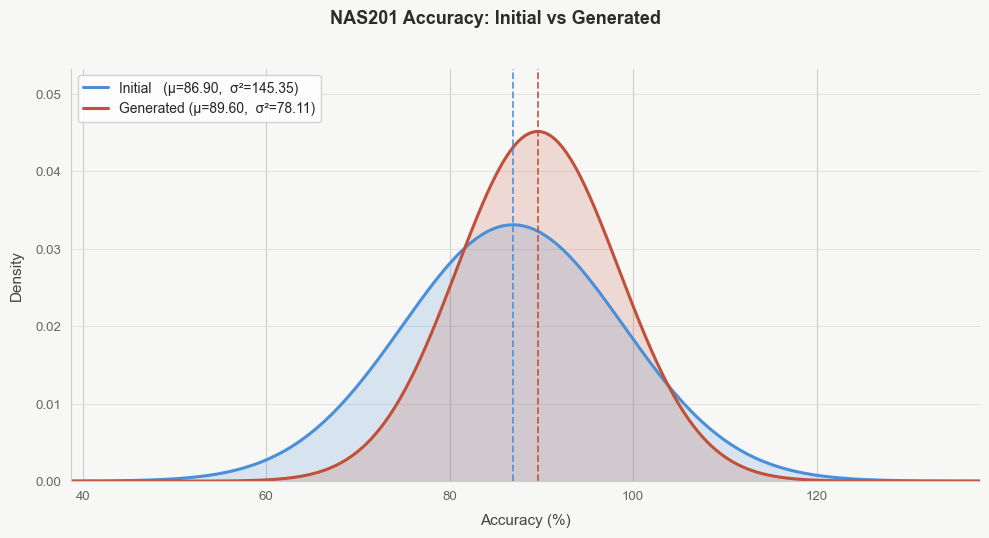

In [ ]:
compare_accuracy_distributions(y_all, new_accs)

## TRAINING LOOP 

**allenamento**
1. allenare ogni volta VAE **provato**
2. early stopping per VAE **provato**
3. congelamento VAE dopo pretrain **provato**
4. VAE con accuracy loss
5. traiettoria flow dopo training **provato**

**per la diversità**

2. elite + diverse + random injection
3. introdurre rumore quando si campiona dal flow
4. alpha non troppo alto, tipo 0.2 o 0.3
5. grafico per capire quanto esplora

si potrebbe tenere sotto controllo la diversità generata, se questa scende sotto tot si aggiunge diversità artificiale

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm


def plot_history_gaussians(
    history,
    title="NAS201 Accuracy distributions across outer epochs",
    save_path=None,
    max_gaussians=5
):
    epochs = np.array(history["epoch"])
    means = np.array(history["mean_acc"], dtype=np.float32)
    stds = np.array(history["std_acc"], dtype=np.float32)

    if len(means) == 0:
        raise ValueError("history è vuoto: non ci sono epoche da plottare.")

    # Se ci sono più epoche di max_gaussians, ne seleziono solo alcune,
    # distribuite uniformemente tra inizio e fine.
    if len(means) > max_gaussians:
        selected_idx = np.linspace(
            0,
            len(means) - 1,
            max_gaussians,
            dtype=int
        )
    else:
        selected_idx = np.arange(len(means))

    epochs_plot = epochs[selected_idx]
    means_plot = means[selected_idx]
    stds_plot = stds[selected_idx]

    # Nel tuo ciclo hai già fatto /100, quindi mean/std sono in [0, 1].
    # Qui le porto in percentuale solo per il grafico.
    means_plot = means_plot * 100.0
    stds_plot = stds_plot * 100.0

    # Evita problemi se una std è zero
    stds_plot = np.maximum(stds_plot, 1e-6)

    # Asse x comune calcolato SOLO sulle gaussiane selezionate
    x_min = np.min(means_plot - 4 * stds_plot)
    x_max = np.max(means_plot + 4 * stds_plot)

    xs = np.linspace(x_min, x_max, 1000)

    BG = "#F7F7F5"

    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_edgecolor("#CCCCCC")
    ax.spines["bottom"].set_edgecolor("#CCCCCC")

    colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(means_plot)))

    max_pdf = 0.0

    for epoch, mu, std, color in zip(epochs_plot, means_plot, stds_plot, colors):
        pdf = norm.pdf(xs, mu, std)
        max_pdf = max(max_pdf, pdf.max())

        ax.fill_between(xs, pdf, alpha=0.10, color=color)

        ax.plot(
            xs,
            pdf,
            color=color,
            linewidth=2.0,
            label=f"Epoch {epoch + 1} (μ={mu:.2f}, σ={std:.2f})"
        )

        ax.axvline(
            mu,
            color=color,
            linewidth=1.1,
            linestyle="--",
            alpha=0.75
        )

    ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.6, linestyle="-", zorder=0)
    ax.set_axisbelow(True)

    ax.set_xlabel("Accuracy (%)", fontsize=11, labelpad=8, color="#444444")
    ax.set_ylabel("Density", fontsize=11, labelpad=8, color="#444444")
    ax.tick_params(colors="#666666", labelsize=9.5)

    ax.set_xlim(xs[0], xs[-1])
    ax.set_ylim(bottom=0, top=max_pdf * 1.18)

    ax.legend(
        fontsize=9,
        framealpha=0.85,
        edgecolor="#CCCCCC",
        loc="upper left",
        handlelength=1.8
    )

    fig.suptitle(
        title,
        fontsize=13,
        fontweight="bold",
        y=0.97,
        color="#2C2C2A"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=160,
            bbox_inches="tight",
            facecolor=fig.get_facecolor()
        )

    plt.show()

# QUA PER FARE UNA SOLA ITERAZIONE DEL TRAIN


In [1]:
from types import SimpleNamespace
from train_flownas import run_training
import torch
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

args = SimpleNamespace(
    outer_epochs=2,
    N=256,
    latent_dim=16,
    batch_size=64,

    weight_sharing = True,


    vae_epochs=200,
    pretrain_vae_epochs=300,
    pretrain_batch_size=64,
    pretrain_fraction=0.2,

    flow_epochs=200,
    alpha=0.5,

    beta=0.0,
    lambda_acc=1.0,

    use_top_mutations=False,
    elite_fraction=0.1,
    mutation_fraction=0.2,
    mutation_k=1,
    benchmark_name = "nas201",
    dataset_name="cifar10",
    nas_hp="200",
    nas_metric="test-accuracy",
    train_dataset = None,
    test_dataset = None,

    seed=42,
    device=DEVICE,
)


tensorflow is not installed.
Using device: cuda


In [2]:
history, model_VAE, flow, test_dataset, api = run_training(args)

Dataset NAS201 già estratto.
Architetture NAS201 totali: 15625
Dataset not available, importing...

 PRETRAIN VAE
VAE pretrain epoch 000 | loss=1.247324 | recon=0.980242 | kl=0.054688 | acc_loss=0.267082
VAE pretrain epoch 050 | loss=0.001599 | recon=0.000185 | kl=46.306483 | acc_loss=0.001414
VAE pretrain epoch 100 | loss=0.001119 | recon=0.000062 | kl=41.376016 | acc_loss=0.001057
VAE pretrain epoch 150 | loss=0.000464 | recon=0.000024 | kl=39.844549 | acc_loss=0.000439
Early stopping: patience reached at epoch 175, best_loss=0.000417
VAE pretrained and frozen.

 OUTER EPOCH 1/2 ==========
z_all shape: torch.Size([256, 16])
y_all shape: torch.Size([256])
Number of pairs: 223
pairs_x shape: torch.Size([223, 16])
pairs_target shape: torch.Size([223, 16])
z_new shape: torch.Size([256, 16])
evaluating nets

Epoch   0 | Batch    0 | Loss (M=4): 2.3336 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch   25 | Loss (M=4): 2.2788 | LR: 0.025000 | Path noti: 254
Epoch   0 | Batch   50 | Loss (

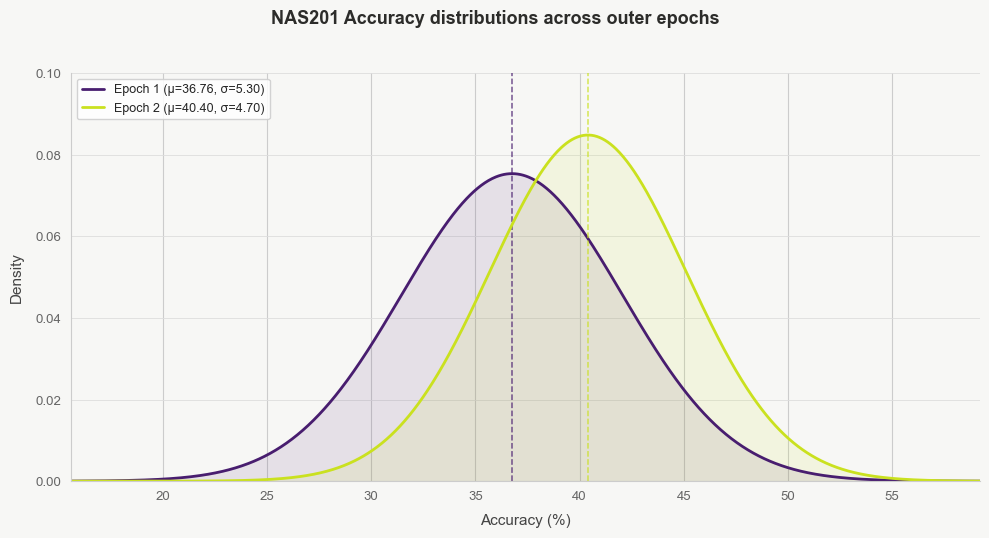

In [5]:
plot_history_gaussians(
    history,
    title="NAS201 Accuracy distributions across outer epochs",
    save_path=None,
    max_gaussians=5
)

In [ ]:
import torch
import pandas as pd
import numpy as np


def api_acc_to_01(acc):
    if acc is None:
        return None
    return float(acc) / 100.0


def recon_probs_to_arch_str(recon_probs_single):
    """
    recon_probs_single: [4, 4, 6]
    """
    x_decoded = recon_probs_single
    x_decoded = x_decoded.permute(2, 0, 1)  # [6, 4, 4]
    x_decoded = x_decoded.reshape(-1)       # [96]

    return decoded_x_to_nas201_arch(x_decoded)


def evaluate_flow_on_worst_percent(
    model_VAE,
    flow,
    test_dataset,
    api,
    dataset_name="cifar10",
    nas_hp="200",
    nas_metric="test-accuracy",
    n_eval=100,
    worst_percent=0.10,
    alpha=0.5,
    seed=42,
    device=DEVICE
):
    DEVICE = torch.device(device)

    model_VAE = model_VAE.to(DEVICE)
    flow = flow.to(DEVICE)

    model_VAE.eval()
    flow.eval()

    # --------------------------------------------------
    # 1. Estraggo tutte le accuracy del test_dataset
    # --------------------------------------------------
    X_all = []
    y_all = []

    for i in range(len(test_dataset)):
        x, y = test_dataset[i]
        X_all.append(x.float())
        y_all.append(float(y))

    X_all = torch.stack(X_all)
    y_all = torch.tensor(y_all).float()

    # y dovrebbe già essere normalizzata in [0, 1]
    if y_all.max() > 1.5:
        y_all = y_all / 100.0

    print("Test dataset:")
    print(f"size      = {len(test_dataset)}")
    print(f"min acc   = {y_all.min().item() * 100:.4f}%")
    print(f"mean acc  = {y_all.mean().item() * 100:.4f}%")
    print(f"max acc   = {y_all.max().item() * 100:.4f}%")

    # --------------------------------------------------
    # 2. Seleziono il peggior worst_percent
    # --------------------------------------------------
    n_low = max(1, int(len(test_dataset) * worst_percent))

    sorted_idx = torch.argsort(y_all)
    low_indices = sorted_idx[:n_low]

    generator = torch.Generator().manual_seed(seed)

    if n_eval <= len(low_indices):
        perm = torch.randperm(
            len(low_indices),
            generator=generator
        )[:n_eval]
        selected_indices = low_indices[perm]
    else:
        # se chiedo più architetture di quante ce ne sono nel low pool,
        # campiono con ripetizione
        rand_pos = torch.randint(
            low=0,
            high=len(low_indices),
            size=(n_eval,),
            generator=generator
        )
        selected_indices = low_indices[rand_pos]

    print()
    print(f"Selected {len(selected_indices)} architectures")
    print(f"from worst {worst_percent * 100:.1f}% of test_dataset")
    print(f"low pool size = {len(low_indices)}")

    # --------------------------------------------------
    # 3. Passo ogni architettura nel flow
    # --------------------------------------------------
    rows = []

    for test_id, idx_tensor in enumerate(selected_indices):

        idx = idx_tensor.item()

        x_start = X_all[idx].unsqueeze(0).to(DEVICE).float()
        acc_start_dataset = y_all[idx].item()

        # architettura iniziale
        x_start_cpu = x_start.squeeze(0).detach().cpu()

        start_arch = decoded_x_to_nas201_arch(
            x_start_cpu.view(-1)
        )

        acc_start_api, _ = query_nas201_accuracy(
            api=api,
            arch_str=start_arch,
            dataset_name=dataset_name,
            hp=nas_hp,
            metric=nas_metric
        )

        acc_start_api = api_acc_to_01(acc_start_api)

        if acc_start_api is None:
            continue

        with torch.no_grad():

            mu, logvar = model_VAE.encode(x_start)
            z_start = mu

            direction = flow(z_start)
            z_new = z_start + alpha * direction

            _, recon_probs_new = model_VAE.decode(z_new)

            generated_arch = recon_probs_to_arch_str(
                recon_probs_new[0].detach().cpu()
            )

        acc_generated_api, _ = query_nas201_accuracy(
            api=api,
            arch_str=generated_arch,
            dataset_name=dataset_name,
            hp=nas_hp,
            metric=nas_metric
        )

        acc_generated_api = api_acc_to_01(acc_generated_api)

        if acc_generated_api is None:
            continue

        delta = acc_generated_api - acc_start_api

        rows.append({
            "test_id": test_id,
            "idx_test_dataset": idx,

            "acc_start_dataset": acc_start_dataset,
            "acc_start_api": acc_start_api,
            "acc_generated_api": acc_generated_api,

            "delta": delta,
            "improved": delta > 0,

            "same_arch": start_arch == generated_arch,

            "start_arch": start_arch,
            "generated_arch": generated_arch,
        })

    df_eval = pd.DataFrame(rows)

    if len(df_eval) == 0:
        print("Nessuna valutazione valida.")
        return df_eval

    # --------------------------------------------------
    # 4. Summary
    # --------------------------------------------------
    print("\n========== FLOW EVALUATION ==========")
    print(f"valid eval             = {len(df_eval)} / {len(selected_indices)}")
    print(f"alpha                  = {alpha}")
    print(f"worst percent          = {worst_percent * 100:.1f}%")

    print(f"mean start acc API     = {df_eval['acc_start_api'].mean() * 100:.4f}%")
    print(f"mean generated acc API = {df_eval['acc_generated_api'].mean() * 100:.4f}%")
    print(f"mean delta             = {df_eval['delta'].mean() * 100:+.4f}%")

    if len(df_eval) > 1:
        print(f"std delta              = {df_eval['delta'].std() * 100:.4f}%")
    else:
        print("std delta              = 0.0000%")

    print(f"min delta              = {df_eval['delta'].min() * 100:+.4f}%")
    print(f"max delta              = {df_eval['delta'].max() * 100:+.4f}%")
    print(f"success rate           = {df_eval['improved'].mean() * 100:.2f}%")
    print(f"same arch rate         = {df_eval['same_arch'].mean() * 100:.2f}%")

    print("\n--- Dataset/API mismatch on start arch ---")
    df_eval["dataset_minus_api"] = (
        df_eval["acc_start_dataset"] - df_eval["acc_start_api"]
    )

    print(f"mean dataset - API     = {df_eval['dataset_minus_api'].mean() * 100:+.6f}%")
    print(f"max abs dataset - API  = {df_eval['dataset_minus_api'].abs().max() * 100:.6f}%")

    return df_eval

In [ ]:
df_eval = evaluate_flow_on_worst_percent(
    model_VAE=model_VAE,
    flow=flow,
    test_dataset=test_dataset,
    api=api,
    dataset_name=args.dataset_name,
    nas_hp=args.nas_hp,
    nas_metric=args.nas_metric,
    n_eval=100,
    worst_percent=0.10,
    alpha=args.alpha,
    seed=123,
    device=args.device
)

Test dataset:
size      = 3125
min acc   = 10.0000%
mean acc  = 87.3392%
max acc   = 94.3433%

Selected 100 architectures
from worst 10.0% of test_dataset
low pool size = 312

========== FLOW EVALUATION ==========
valid eval             = 100 / 100
alpha                  = 0.5
worst percent          = 10.0%
mean start acc API     = 61.4734%
mean generated acc API = 82.9119%
mean delta             = +21.4385%
std delta              = 32.7034%
min delta              = -65.9700%
max delta              = +82.7500%
success rate           = 89.00%
same arch rate         = 0.00%

--- Dataset/API mismatch on start arch ---
mean dataset - API     = +0.000000%
max abs dataset - API  = 0.000006%


In [ ]:
import torch
import pandas as pd
import numpy as np


def api_acc_to_01(acc):
    if acc is None:
        return None
    return float(acc) / 100.0


def recon_probs_to_arch_str(recon_probs_single):
    """
    recon_probs_single: [4, 4, 6]
    """
    x_decoded = recon_probs_single
    x_decoded = x_decoded.permute(2, 0, 1)  # [6, 4, 4]
    x_decoded = x_decoded.reshape(-1)       # [96]

    return decoded_x_to_nas201_arch(x_decoded)


def evaluate_flow_vs_random_on_worst_percent(
    model_VAE,
    flow,
    test_dataset,
    api,
    dataset_name="cifar10",
    nas_hp="200",
    nas_metric="test-accuracy",
    n_eval=100,
    worst_percent=0.10,
    alpha=0.5,
    seed=42,
    device=DEVICE
):
    DEVICE = torch.device(device)

    model_VAE = model_VAE.to(DEVICE)
    flow = flow.to(DEVICE)

    model_VAE.eval()
    flow.eval()

    # --------------------------------------------------
    # 1. Estraggo X e y dal test_dataset
    # --------------------------------------------------
    X_all = []
    y_all = []

    for i in range(len(test_dataset)):
        x, y = test_dataset[i]
        X_all.append(x.float())
        y_all.append(float(y))

    X_all = torch.stack(X_all)
    y_all = torch.tensor(y_all).float()

    if y_all.max() > 1.5:
        y_all = y_all / 100.0

    print("Test dataset:")
    print(f"size      = {len(test_dataset)}")
    print(f"min acc   = {y_all.min().item() * 100:.4f}%")
    print(f"mean acc  = {y_all.mean().item() * 100:.4f}%")
    print(f"max acc   = {y_all.max().item() * 100:.4f}%")

    # --------------------------------------------------
    # 2. Seleziono il peggior worst_percent
    # --------------------------------------------------
    n_low = max(1, int(len(test_dataset) * worst_percent))

    sorted_idx = torch.argsort(y_all)
    low_indices = sorted_idx[:n_low]

    generator = torch.Generator().manual_seed(seed)

    if n_eval <= len(low_indices):
        perm = torch.randperm(
            len(low_indices),
            generator=generator
        )[:n_eval]
        selected_indices = low_indices[perm]
    else:
        rand_pos = torch.randint(
            low=0,
            high=len(low_indices),
            size=(n_eval,),
            generator=generator
        )
        selected_indices = low_indices[rand_pos]

    print()
    print(f"Selected {len(selected_indices)} architectures")
    print(f"from worst {worst_percent * 100:.1f}% of test_dataset")
    print(f"low pool size = {len(low_indices)}")

    # --------------------------------------------------
    # 3. Passo ogni architettura nel flow e in random
    # --------------------------------------------------
    rows = []

    for test_id, idx_tensor in enumerate(selected_indices):

        idx = idx_tensor.item()

        x_start = X_all[idx].unsqueeze(0).to(DEVICE).float()
        acc_start_dataset = y_all[idx].item()

        x_start_cpu = x_start.squeeze(0).detach().cpu()

        start_arch = decoded_x_to_nas201_arch(
            x_start_cpu.view(-1)
        )

        acc_start_api, _ = query_nas201_accuracy(
            api=api,
            arch_str=start_arch,
            dataset_name=dataset_name,
            hp=nas_hp,
            metric=nas_metric
        )

        acc_start_api = api_acc_to_01(acc_start_api)

        if acc_start_api is None:
            continue

        with torch.no_grad():

            # Encode
            mu, logvar = model_VAE.encode(x_start)
            z_start = mu

            # -------------------------------
            # FLOW direction
            # -------------------------------
            flow_direction = flow(z_start)

            z_flow = z_start + alpha * flow_direction

            _, recon_probs_flow = model_VAE.decode(z_flow)

            flow_arch = recon_probs_to_arch_str(
                recon_probs_flow[0].detach().cpu()
            )

            # -------------------------------
            # RANDOM direction
            # stessa norma della direzione flow
            # -------------------------------
            random_direction = torch.randn_like(flow_direction)

            flow_norm = flow_direction.norm(dim=1, keepdim=True)
            random_norm = random_direction.norm(dim=1, keepdim=True)

            random_direction = random_direction / (random_norm + 1e-8)
            random_direction = random_direction * flow_norm

            z_random = z_start + alpha * random_direction

            _, recon_probs_random = model_VAE.decode(z_random)

            random_arch = recon_probs_to_arch_str(
                recon_probs_random[0].detach().cpu()
            )

        # --------------------------------------------------
        # Accuracy API
        # --------------------------------------------------
        acc_flow_api, _ = query_nas201_accuracy(
            api=api,
            arch_str=flow_arch,
            dataset_name=dataset_name,
            hp=nas_hp,
            metric=nas_metric
        )

        acc_flow_api = api_acc_to_01(acc_flow_api)

        acc_random_api, _ = query_nas201_accuracy(
            api=api,
            arch_str=random_arch,
            dataset_name=dataset_name,
            hp=nas_hp,
            metric=nas_metric
        )

        acc_random_api = api_acc_to_01(acc_random_api)

        if acc_flow_api is None or acc_random_api is None:
            continue

        delta_flow = acc_flow_api - acc_start_api
        delta_random = acc_random_api - acc_start_api

        rows.append({
            "test_id": test_id,
            "idx_test_dataset": idx,

            "acc_start_dataset": acc_start_dataset,
            "acc_start_api": acc_start_api,

            "acc_flow_api": acc_flow_api,
            "acc_random_api": acc_random_api,

            "delta_flow": delta_flow,
            "delta_random": delta_random,
            "flow_minus_random": delta_flow - delta_random,

            "flow_improved": delta_flow > 0,
            "random_improved": delta_random > 0,
            "flow_better_than_random": delta_flow > delta_random,

            "same_flow_arch": start_arch == flow_arch,
            "same_random_arch": start_arch == random_arch,

            "start_arch": start_arch,
            "flow_arch": flow_arch,
            "random_arch": random_arch,
        })

    df_eval = pd.DataFrame(rows)

    if len(df_eval) == 0:
        print("Nessuna valutazione valida.")
        return df_eval

    # --------------------------------------------------
    # 4. Summary
    # --------------------------------------------------
    print("\n========== FLOW vs RANDOM EVALUATION ==========")
    print(f"valid eval              = {len(df_eval)} / {len(selected_indices)}")
    print(f"alpha                   = {alpha}")
    print(f"worst percent           = {worst_percent * 100:.1f}%")

    print(f"\nmean start acc API      = {df_eval['acc_start_api'].mean() * 100:.4f}%")
    print(f"mean flow acc API       = {df_eval['acc_flow_api'].mean() * 100:.4f}%")
    print(f"mean random acc API     = {df_eval['acc_random_api'].mean() * 100:.4f}%")

    print(f"\nmean delta flow         = {df_eval['delta_flow'].mean() * 100:+.4f}%")
    print(f"mean delta random       = {df_eval['delta_random'].mean() * 100:+.4f}%")
    print(f"mean flow - random      = {df_eval['flow_minus_random'].mean() * 100:+.4f}%")

    if len(df_eval) > 1:
        print(f"\nstd delta flow          = {df_eval['delta_flow'].std() * 100:.4f}%")
        print(f"std delta random        = {df_eval['delta_random'].std() * 100:.4f}%")
        print(f"std flow - random       = {df_eval['flow_minus_random'].std() * 100:.4f}%")
    else:
        print("\nstd delta flow          = 0.0000%")
        print("std delta random        = 0.0000%")
        print("std flow - random       = 0.0000%")

    print(f"\nflow success rate       = {df_eval['flow_improved'].mean() * 100:.2f}%")
    print(f"random success rate     = {df_eval['random_improved'].mean() * 100:.2f}%")
    print(f"flow better rate        = {df_eval['flow_better_than_random'].mean() * 100:.2f}%")

    print(f"\nsame flow arch rate     = {df_eval['same_flow_arch'].mean() * 100:.2f}%")
    print(f"same random arch rate   = {df_eval['same_random_arch'].mean() * 100:.2f}%")

    print("\n--- Dataset/API mismatch on start arch ---")
    df_eval["dataset_minus_api"] = (
        df_eval["acc_start_dataset"] - df_eval["acc_start_api"]
    )

    print(f"mean dataset - API      = {df_eval['dataset_minus_api'].mean() * 100:+.6f}%")
    print(f"max abs dataset - API   = {df_eval['dataset_minus_api'].abs().max() * 100:.6f}%")

    return df_eval

NameError: name 'DEVICE' is not defined

In [ ]:
df_eval_random = evaluate_flow_vs_random_on_worst_percent(
    model_VAE=model_VAE,
    flow=flow,
    test_dataset=test_dataset,
    api=api,
    dataset_name=args.dataset_name,
    nas_hp=args.nas_hp,
    nas_metric=args.nas_metric,
    n_eval=100,
    worst_percent=0.10,
    alpha=args.alpha,
    seed=123,
    device=args.device
)

Test dataset:
size      = 3125
min acc   = 10.0000%
mean acc  = 87.3392%
max acc   = 94.3433%

Selected 100 architectures
from worst 10.0% of test_dataset
low pool size = 312

========== FLOW vs RANDOM EVALUATION ==========
valid eval              = 100 / 100
alpha                   = 0.5
worst percent           = 10.0%

mean start acc API      = 61.4734%
mean flow acc API       = 82.9119%
mean random acc API     = 74.9918%

mean delta flow         = +21.4385%
mean delta random       = +13.5185%
mean flow - random      = +7.9200%

std delta flow          = 32.7034%
std delta random        = 31.8215%
std flow - random       = 33.4510%

flow success rate       = 89.00%
random success rate     = 74.00%
flow better rate        = 67.00%

same flow arch rate     = 0.00%
same random arch rate   = 3.00%

--- Dataset/API mismatch on start arch ---
mean dataset - API      = +0.000000%
max abs dataset - API   = 0.000006%


In [ ]:
from types import SimpleNamespace

all_summaries = []
all_eval_dfs = []
all_histories = []
n_train_runs = 1

for run_id in range(n_train_runs):

    print(f"\n\n================ TRAINING RUN {run_id + 1}/{n_train_runs} ================")

    seed = 42 + run_id

    args = SimpleNamespace(
        outer_epoch= 2,
        N=256,
        latent_dim=16,
        batch_size=64,
        
        weight_sharing = True,

        vae_epochs=200,
        pretrain_vae_epochs=300,
        pretrain_batch_size=64,
        pretrain_fraction=0.1,

        flow_epochs=200,
        alpha=0.5,

        weight_sharing = False,

        beta=0.0,
        lambda_acc= 1,

        use_top_mutations=False,
        elite_fraction=0.1,
        mutation_fraction=0.2,
        mutation_k=1,

        benchmark_name = "nas201",
        dataset_name="cifar10", #cifar10, ImageNet16-120 
        nas_hp="200",
        nas_metric="test-accuracy",

        train_dataset=train_dataset,
        test_dataset=test_dataset,

        seed=seed,
        device=DEVICE,

        api=api,
    )

    # --------------------------------------------------
    # 1. Training del modello
    # --------------------------------------------------
    history, model_VAE, flow, test_dataset_out, api_out = run_training(args)

    all_histories.append({
        "run_id": run_id,
        "seed": seed,
        "history": history,
    })

    # --------------------------------------------------
    # 2. Test flow vs random su 100 architetture
    # --------------------------------------------------
    df_eval = evaluate_flow_vs_random_on_worst_percent(
        model_VAE=model_VAE,
        flow=flow,
        test_dataset=test_dataset_out,
        api=api_out,
        dataset_name=args.dataset_name,
        nas_hp=args.nas_hp,
        nas_metric=args.nas_metric,
        n_eval=100,
        worst_percent=0.80,
        alpha=args.alpha,
        seed=10_000 + run_id,
        device=args.device
    )

    if len(df_eval) == 0:
        print("Run senza valutazioni valide, salto summary.")
        continue

    df_eval["run_id"] = run_id
    df_eval["seed"] = seed

    all_eval_dfs.append(df_eval)

    # --------------------------------------------------
    # 3. Summary della singola run
    # --------------------------------------------------
    summary = {
        "run_id": run_id,
        "seed": seed,
        "valid_eval": len(df_eval),

        "mean_start_acc": df_eval["acc_start_api"].mean(),
        "mean_flow_acc": df_eval["acc_flow_api"].mean(),
        "mean_random_acc": df_eval["acc_random_api"].mean(),

        "mean_delta_flow": df_eval["delta_flow"].mean(),
        "mean_delta_random": df_eval["delta_random"].mean(),
        "mean_flow_minus_random": df_eval["flow_minus_random"].mean(),

        "flow_success_rate": df_eval["flow_improved"].mean(),
        "random_success_rate": df_eval["random_improved"].mean(),
        "flow_better_rate": df_eval["flow_better_than_random"].mean(),

        "same_flow_arch_rate": df_eval["same_flow_arch"].mean(),
        "same_random_arch_rate": df_eval["same_random_arch"].mean(),
    }

    all_summaries.append(summary)

    print("\n--- RUN SUMMARY ---")
    print(f"valid eval              = {summary['valid_eval']}")
    print(f"mean start acc          = {summary['mean_start_acc'] * 100:.4f}%")
    print(f"mean flow acc           = {summary['mean_flow_acc'] * 100:.4f}%")
    print(f"mean random acc         = {summary['mean_random_acc'] * 100:.4f}%")
    print(f"mean delta flow         = {summary['mean_delta_flow'] * 100:+.4f}%")
    print(f"mean delta random       = {summary['mean_delta_random'] * 100:+.4f}%")
    print(f"flow - random           = {summary['mean_flow_minus_random'] * 100:+.4f}%")
    print(f"flow better rate        = {summary['flow_better_rate'] * 100:.2f}%")



================ TRAINING RUN 1/1 ================


NameError: name 'train_dataset' is not defined

In [ ]:
df_summary = pd.DataFrame(all_summaries)
df_all_eval = pd.concat(all_eval_dfs, ignore_index=True)

print("\n\n================ FINAL SUMMARY OVER 100 TRAINING RUNS ================")

print(f"training runs completed     = {len(df_summary)}")
print(f"total evaluated archs       = {len(df_all_eval)}")

print(f"\nmean start acc              = {df_summary['mean_start_acc'].mean() * 100:.4f}%")
print(f"mean flow acc               = {df_summary['mean_flow_acc'].mean() * 100:.4f}%")
print(f"mean random acc             = {df_summary['mean_random_acc'].mean() * 100:.4f}%")

print(f"\nmean delta flow             = {df_summary['mean_delta_flow'].mean() * 100:+.4f}%")
print(f"std delta flow              = {df_summary['mean_delta_flow'].std() * 100:.4f}%")

print(f"\nmean delta random           = {df_summary['mean_delta_random'].mean() * 100:+.4f}%")
print(f"std delta random            = {df_summary['mean_delta_random'].std() * 100:.4f}%")

print(f"\nmean flow - random          = {df_summary['mean_flow_minus_random'].mean() * 100:+.4f}%")
print(f"std flow - random           = {df_summary['mean_flow_minus_random'].std() * 100:.4f}%")

print(f"\nflow success rate           = {df_summary['flow_success_rate'].mean() * 100:.2f}%")
print(f"random success rate         = {df_summary['random_success_rate'].mean() * 100:.2f}%")
print(f"flow better rate            = {df_summary['flow_better_rate'].mean() * 100:.2f}%")

print(f"\nsame flow arch rate         = {df_summary['same_flow_arch_rate'].mean() * 100:.2f}%")
print(f"same random arch rate       = {df_summary['same_random_arch_rate'].mean() * 100:.2f}%")



================ FINAL SUMMARY OVER 100 TRAINING RUNS ================
training runs completed     = 20
total evaluated archs       = 2000

mean start acc              = 31.5349%
mean flow acc               = 36.1029%
mean random acc             = 31.6038%

mean delta flow             = +4.5680%
std delta flow              = 1.9150%

mean delta random           = +0.0689%
std delta random            = 1.3171%

mean flow - random          = +4.4991%
std flow - random           = 1.7733%

flow success rate           = 69.70%
random success rate         = 51.15%
flow better rate            = 65.65%

same flow arch rate         = 0.45%
same random arch rate       = 2.95%


## testing on NAS301

### loading data

In [ ]:
from latent_space.model import VAE_nas301

In [ ]:
import pandas as pd

def load_csv_as_dataset(csv_path):
    df = pd.read_csv(csv_path)

    # Prendo tutte le colonne x_0, x_1, ..., x_n
    feature_cols = [col for col in df.columns if col.startswith("x_")]

    # Ordino correttamente: x_0, x_1, ..., x_503
    feature_cols = sorted(
        feature_cols,
        key=lambda c: int(c.split("_")[1])
    )

    X = df[feature_cols].values
    Y = df["accuracy"].values

    X = torch.tensor(X, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)

    dataset = TensorDataset(X, Y)

    print("CSV caricato:", csv_path)
    print("Numero esempi:", len(dataset))
    print("X shape:", X.shape)
    print("Y shape:", Y.shape)
    print("Accuracy min:", Y.min().item())
    print("Accuracy max:", Y.max().item())

    return X, Y, dataset

X, Y, dataset_301 = load_csv_as_dataset(
    "nas301/nas301_dataset.csv"
)

CSV caricato: nas301/nas301_dataset.csv
Numero esempi: 50000
X shape: torch.Size([50000, 504])
Y shape: torch.Size([50000])
Accuracy min: 0.8962019085884094
Accuracy max: 0.9467961192131042


In [ ]:
train_size = int(0.8 * len(dataset_301))
test_size = len(dataset_301) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, test_dataset = random_split(
    dataset_301,
    [train_size, test_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 40000
Test size: 10000


In [ ]:
from types import SimpleNamespace
from train_flownas import run_training

args = SimpleNamespace(
    # Benchmark
    benchmark_name="NAS301",
    n_samples=1000,          # piccolo per test veloce
    performance_model=None,  # lo carica la factory se return_model=True

    # Training
    outer_epochs=20,
    N=1024,
    latent_dim=32,
    batch_size=64,

    # VAE
    vae_epochs=5,
    pretrain_vae_epochs=200,
    pretrain_batch_size=64,
    pretrain_fraction=0.5,

    # Flow
    flow_epochs=5,
    alpha=0.5,

    # Loss
    beta=0.0,
    lambda_acc=1.0,
    #weight_sharing
    weight_sharing = True;
    # Population
    use_top_mutations=False,
    elite_fraction=0.2,
    mutation_fraction=0.2,
    mutation_k=1,

    # NAS201 placeholders, non usati per NAS301
    benchmark_mane = "nas301",
    dataset_name="cifar10",
    nas_hp=None,
    nas_metric="surrogate_accuracy",
    weight_sharing = False, 
    # Dataset già disponibile o no
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    pos_weight_value = 5,

    # System
    seed=42,
    device="cuda",
)

history, model_VAE, flow, test_dataset, api_or_model = run_training(args)

Pesi NAS-Bench-301 trovati localmente.
[11:20:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

[11:20:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en

c:\Users\tiber\Desktop\em\ALife\Deep-Learning-Project\latent_space\dataset_loader.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)



Generated NAS301 architectures from FLOW:
valid archs = 1024 / 1024
mean acc    = 0.9315
std acc     = 0.0059
min acc     = 0.9067
max acc     = 0.9443

Next population NAS301:
generated unique flow archs = 1024
selected flow archs         = 820
selected elite archs        = 204
before duplicate removal    = 1024
after duplicate removal     = 1022
final population size       = 1024
mean acc                    = 0.9346
max acc                     = 0.9450

 OUTER EPOCH 2/20 ==========
Skipping VAE training: using frozen/pretrained VAE.
z_all shape: torch.Size([1024, 32])
y_all shape: torch.Size([1024])
pairs_x shape: torch.Size([1008, 32])
pairs_target shape: torch.Size([1008, 32])
Flow epoch 000 | loss=0.599381
z_new shape: torch.Size([1024, 32])


c:\Users\tiber\Desktop\em\ALife\Deep-Learning-Project\latent_space\dataset_loader.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)



Generated NAS301 architectures from FLOW:
valid archs = 1024 / 1024
mean acc    = 0.9340
std acc     = 0.0051
min acc     = 0.9114
max acc     = 0.9475

Next population NAS301:
generated unique flow archs = 1024
selected flow archs         = 820
selected elite archs        = 204
before duplicate removal    = 1024
after duplicate removal     = 1021
final population size       = 1024
mean acc                    = 0.9367
max acc                     = 0.9475

 OUTER EPOCH 3/20 ==========
Skipping VAE training: using frozen/pretrained VAE.
z_all shape: torch.Size([1024, 32])
y_all shape: torch.Size([1024])
pairs_x shape: torch.Size([1012, 32])
pairs_target shape: torch.Size([1012, 32])
Flow epoch 000 | loss=0.467752
z_new shape: torch.Size([1024, 32])


...


Generated NAS301 architectures from FLOW:
valid archs = 1024 / 1024
mean acc    = 0.9422
std acc     = 0.0027
min acc     = 0.9316
max acc     = 0.9478

Next population NAS301:
generated unique flow archs = 906
selected flow archs         = 820
selected elite archs        = 204
before duplicate removal    = 1024
after duplicate removal     = 982
final population size       = 1024
mean acc                    = 0.9429
max acc                     = 0.9480

 OUTER EPOCH 19/20 ==========
Skipping VAE training: using frozen/pretrained VAE.
z_all shape: torch.Size([1024, 32])
y_all shape: torch.Size([1024])
pairs_x shape: torch.Size([1011, 32])
pairs_target shape: torch.Size([1011, 32])
Flow epoch 000 | loss=0.159552
z_new shape: torch.Size([1024, 32])


c:\Users\tiber\Desktop\em\ALife\Deep-Learning-Project\latent_space\dataset_loader.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)



Generated NAS301 architectures from FLOW:
valid archs = 1024 / 1024
mean acc    = 0.9420
std acc     = 0.0029
min acc     = 0.9263
max acc     = 0.9479

Next population NAS301:
generated unique flow archs = 923
selected flow archs         = 820
selected elite archs        = 204
before duplicate removal    = 1024
after duplicate removal     = 979
final population size       = 1024
mean acc                    = 0.9429
max acc                     = 0.9480

 OUTER EPOCH 20/20 ==========
Skipping VAE training: using frozen/pretrained VAE.
z_all shape: torch.Size([1024, 32])
y_all shape: torch.Size([1024])
pairs_x shape: torch.Size([1008, 32])
pairs_target shape: torch.Size([1008, 32])
Flow epoch 000 | loss=0.157844
z_new shape: torch.Size([1024, 32])


c:\Users\tiber\Desktop\em\ALife\Deep-Learning-Project\latent_space\dataset_loader.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)



Generated NAS301 architectures from FLOW:
valid archs = 1024 / 1024
mean acc    = 0.9422
std acc     = 0.0027
min acc     = 0.9325
max acc     = 0.9479

Next population NAS301:
generated unique flow archs = 905
selected flow archs         = 820
selected elite archs        = 204
before duplicate removal    = 1024
after duplicate removal     = 985
final population size       = 1024
mean acc                    = 0.9430
max acc                     = 0.9480
